In [4]:
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter
import string

from flonacomldft.utils.diagnostics import avg_windows

from flonacomldft.utils.plots import (
    set_plot_sequential_data,
    load_ag6_image,
    plot_energy_histogram,
)

from flonacomldft.utils.diagnostics import R_hat
import torch
from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file, 
    get_project_path
)

import cmocean.cm as cmo

sns.set()

# science format
science = {
            # Set line widths
            'axes.linewidth' : 1,
            'grid.linewidth' : 1,

            # Remove legend frame
            #'legend.frameon' : False,

            # Always save as 'tight'
            'savefig.bbox' : 'tight',
            'savefig.pad_inches' : 0.05,

            # Use serif fonts
            # 'font.serif' : 'Times',
            'font.family' : 'serif',
            'mathtext.fontset' : 'dejavuserif',
    
            # Set y axis
            'ytick.direction' : 'out',
            'ytick.major.size' : 3,
            'ytick.major.width' : 0.5,
            'ytick.minor.size' : 1.5,
            'ytick.minor.width' : 0.5,
            'ytick.minor.visible' : True,

            # Set x axis
            'xtick.direction' : 'out',
            'xtick.major.size' : 3,
            'xtick.major.width' : 0.5,
            'xtick.minor.size' : 1.5,
            'xtick.minor.width' : 0.5,
            'xtick.minor.visible' : True
           }

# set sns theme with science format
sns.set_theme(style='ticks', rc=science)

model_colors = dict(zip(['ab-flowMC w.o NP', 'ab-flowMC', 'MD'],
                        ['#0077BB', '#CC3311', '#cdb332']))

sns.color_palette(model_colors.values())


[(0.0, 0.4666666666666667, 0.7333333333333333),
 (0.8, 0.2, 0.06666666666666667),
 (0.803921568627451, 0.7019607843137254, 0.19607843137254902)]

## Figure 1

In [5]:
def set_plot_figure_1(
    cvs,
    flow_samples,
    accs,
    rhat,
    energies,
    np_predictions,
    isomer,
    colors,
    figsize=(5.2, 1.9),
    fontsize=30,
    size_axes_label=28,
    size_tick_label=28,
    size_legend=20,
    linewidth=4,
    markersize=20,
    hspace=0.35,
    wspace=0.35,
):

    ncols = 4
    nrows = 2
    
    CV1_label, CV2_label, Method = cvs.columns

    sns.set_context("paper", rc={"font.size":fontsize,
                        "axes.titlesize":fontsize,
                        "axes.labelsize":size_axes_label,
                        "xtick.labelsize":size_tick_label,
                        "ytick.labelsize":size_tick_label,
                        "legend.fontsize":size_tick_label,
                        })   

    # ------ SET FIGURE SIZE ------

    fig, axs = plt.subplots(ncols=ncols, 
                    nrows=nrows, 
                    figsize=figsize,
                    gridspec_kw={#'width_ratios': [1.85, 0.15, 2, 1.5, 0.5],
                                #'height_ratios': [1, 1],
                                'wspace': wspace,
                                'hspace': hspace})

    # ------ SET BIG SUPLOT ------

    gs = axs[0, 0].get_gridspec()

    for ax in axs[:2, :2].ravel():
        ax.remove()
    
    axbig = fig.add_subplot(gs[0:, :2])

    # ------ NUMERAL TO SUBPLOT ------

    posx = -0.05
    posy = 1.05

    axbig.text(posx+0.025,
            posy-0.025, 
            string.ascii_uppercase[0], 
            transform=axbig.transAxes, 
            weight='bold',)

    axbig.spines[['right', 'top']].set_visible(False)

    for n, ax in enumerate(axs[:, 2:].ravel()):
        ax.text(posx,
        posy, 
        string.ascii_uppercase[n+1], 
        transform=ax.transAxes, 
        weight='bold')

        ax.spines[['right', 'top']].set_visible(False)


    # ------ PLOT COLLECTIVE VARIABLES ------

    sns.kdeplot(
        data=flow_samples, x=CV1_label, y=CV2_label,# hue='NLL',
        fill=False, common_norm=False, color="black",
        #cmap='autumn',
        levels=6, linestyle=':', linewidths=linewidth,
        ax=axbig)

    sns.scatterplot(
            data=cvs,
            x=CV1_label, 
            y=CV2_label, 
            hue=Method,
            ax=axbig,
            palette=colors,
            s=markersize*10,
            zorder=2.5,
            marker='o',
            alpha=1,
        )
    
    axbig.set_xlabel(CV1_label)
    axbig.set_ylabel(CV2_label)

    axbig.xaxis.set_major_locator(plt.MaxNLocator(5))
    axbig.yaxis.set_major_locator(plt.MaxNLocator(6))            

    # ------ PLOT ISOMER IMAGE ------

    l, b, h, w = axs[1][0].get_position().get_points().flatten()
    ax2 = fig.add_axes([l*0.005, b*1.05, w*0.9, h*0.9])
    ax2.imshow(load_ag6_image(isomer))
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_axis_off()

    # ------ PLOT ACCEPTANCE RATIO ------

    for key in accs.keys():
        sns.lineplot(accs[key],
            alpha=0.1,
            color=colors[key],
            linewidth=linewidth*0.5,
            ax=axs[0][2],
            )
        accs_avg = avg_windows(accs[key], 
                               window_size=40, 
                               axis=1)
        sns.lineplot(accs_avg,
            color=colors[key],
            linewidth=linewidth,
            ax=axs[0][2],
            )
    
    axs[0][2].set_ylabel("Acceptance ratio")
    #axs[0][2].set_xlabel("MCMC steps")

    #axs[0][2].xaxis.set_major_locator(plt.MaxNLocator(4))
    #axs[0][2].yaxis.set_major_locator(plt.MaxNLocator(4))

    # ------ PLOT RHAT ------

    markers = ['o', 's', '^']
    linestyles = ['dashed', 'dotted', '-']

    for key in rhat.keys():
        for i in range(rhat[key][0].shape[-1]):
            sns.lineplot(x=rhat[key][1], 
                        y=rhat[key][0][:, i], 
                        linestyle=linestyles[i], 
                        marker=markers[i],
                        markersize=markersize,
                        linewidth=linewidth,
                        color=colors[key], 
                        label=rhat[key][2][i],
                        ax=axs[1][2],
                        legend=False)
    
    axs[1][2].axhline(1, c='k', ls='--', 
                  linewidth=linewidth)
    axs[1][2].axhline(1.01, c='grey', ls='--', 
                  linewidth=linewidth)

    axs[1][2].set_xlabel('Steps')
    axs[1][2].set_ylabel(r'$\hat{R}$')

    axs[1][2].sharex(axs[0][2])
    plt.setp(axs[0][2].get_xticklabels(), visible=False)



    #axs[1][2].xaxis.set_major_locator(plt.MaxNLocator(4))
    #axs[1][2].yaxis.set_major_locator(plt.MaxNLocator(4))

    # ------ PLOT MANUAL LEGEND FOR RHAT ------
    
    patches = [ axs[1][2].plot([],[], 
                               marker=markers[i], 
                               linestyle=linestyles[i], 
                               linewidth=linewidth, 
                               markersize=markersize, 
                               color='black', 
                label="{:s}".format(rhat[key][2][i]) )[0]  for i in range(len(rhat[key][2])) ]
    
    patches = patches + [ axs[1][2].plot([],[],  
                               linestyle='dashed', 
                               linewidth=linewidth, 
                               color='gray', 
                label="{:s}".format('Convergence criteria') )[0] ]
    
    axs[1][2].legend(handles=patches, fontsize=size_legend)

    axs[1][2].xaxis.set_major_locator(plt.MaxNLocator(4))
    axs[1][2].yaxis.set_major_locator(plt.MaxNLocator(4))

    # ------ PLOT ENERGY HISTOGRAM ------

    sns.histplot(energies, 
                stat='density',
                bins=20,
                alpha=0.1,
                palette=colors,
                element='step',
                linewidth=linewidth,
                ax=axs[0][3], 
                common_bins=False, 
                common_norm=False,
                legend=False, 
                )

    #axs[0][3].set_xlabel('Potential energy (eV)')
    axs[0][3].set_ylabel('Density (u.a.)')

    # ------ PLOT NP PREDICTIONS --------

    palette_predictions = dict(zip(['train', 'test'], 
                                    #['#009988', '#882255'],
                                    ['#8f230b', '#f27e64']
                                    ))

    for key, marker in zip(['train', 'test'], ['p', 'X']):

        sns.scatterplot(x=np_predictions['datasets'][key].detach().numpy().flatten(),
                y=np_predictions['prediction'][key].detach().numpy().flatten(),
                label=key.capitalize(),
                s=markersize*10,
                ax=axs[1][3],
                color=palette_predictions[key],
                marker=marker,
            )
        
        axs[1][3].legend(fontsize=size_legend)
        axs[1][3].set_xlabel('Potential energy (eV)')
        axs[1][3].set_ylabel('NP prediction (eV)')
    
    axs[1][3].sharex(axs[0][3])
    plt.setp(axs[0][3].get_xticklabels(), visible=False)


    # ------ PLOT FINAL LEGEND ------

    handles, labels = axbig.get_legend_handles_labels()
    
    fig.legend(handles, labels, loc='upper center', 
            bbox_to_anchor=(0.5, 0.01),
            ncol=3, 
            fancybox=True, 
            shadow=True, 
            markerscale=markersize/5)

    axbig.get_legend().remove()

In [6]:
torch.manual_seed(15)

In [7]:
#CV1_label = 'CV1' 
#CV2_label = 'CV2'
CV1_label = 'Coordination number'
CV2_label = 'Radius of gyration'

In [8]:
keys = ['ab-flowMC w.o NP', 'ab-flowMC', 'MD']
save_plot_data = "data_for_plots"

In [9]:
adaptive_info_is0 = load_pickle_file('deprecated/ab-initio-flow-is0.pkl', get_project_path() + '/' + save_plot_data)
adaptive_info_is1 = load_pickle_file('deprecated/ab-initio-flow-is1.pkl', get_project_path() + '/' + save_plot_data)

In [10]:
np_predictions = load_pickle_file('deprecated/np_predictions_ab-flowMC.pkl', get_project_path() + '/' + save_plot_data)
flow_samples = load_pickle_file('deprecated/flow_samples_ab-flowMC.pkl', get_project_path() + '/' + save_plot_data)

In [11]:
is0_md = load_csv_file('is0_flow_train.csv', get_project_path() + '/database/andersen/datasets')
is1_md = load_csv_file('is1_flow_train.csv', get_project_path() + '/database/andersen/datasets')

In [12]:
plot_data_is0 = {
    'isomer' : 0,
    'keys' : keys,
    'accs' : {key: adaptive_info_is0[key]['accs'] for key in keys if key != 'MD'},
    'us' : {key: adaptive_info_is0[key]['us'] for key in keys if key != 'MD'},
    'nlls' : {key: torch.cat(adaptive_info_is0[key]['nlls']) for key in keys if key != 'MD'},
    'energies' : {key: adaptive_info_is0[key]['us'].flatten().detach().numpy() for key in keys if key != 'MD'},
    'cvs' : {key: adaptive_info_is0[key]['cvs'].reshape(-1, 2) for key in keys if key != 'MD'},
    'rhat' : {key: R_hat(torch.cat((adaptive_info_is0[key]['cvs'].reshape(600, 50, 2), adaptive_info_is0[key]['us'].reshape(600, 50, 1)), dim=2).detach().numpy().transpose(1, 0, 2), 
                    labels=[CV1_label, CV2_label, 'Energy']) for key in keys if key != 'MD'}
}

plot_data_is0['np_predictions'] = np_predictions[0]
plot_data_is0['flow_samples'] = pd.DataFrame(flow_samples[0].squeeze(), columns=[CV1_label, CV2_label, 'NLL'])

plot_data_is0['cvs']['MD'] = is0_md[:, -2:]
plot_data_is0['energies']['MD'] = is0_md[:, 12]

In [13]:
plot_data_is1 = {
    'isomer' : 1,
    'keys' : keys,
    'accs' : {key: adaptive_info_is1[key]['accs'] for key in keys if key != 'MD'},
    'us' : {key: adaptive_info_is1[key]['us'] for key in keys if key != 'MD'},
    'nlls' : {key: torch.cat(adaptive_info_is1[key]['nlls']) for key in keys if key != 'MD'},
    'energies' : {key: adaptive_info_is1[key]['us'].flatten().detach().numpy() for key in keys if key != 'MD'},
    'cvs' : {key: adaptive_info_is1[key]['cvs'].reshape(-1, 2) for key in keys if key != 'MD'},
    'rhat' : {key: R_hat(torch.cat((adaptive_info_is1[key]['cvs'].reshape(600, 50, 2), adaptive_info_is1[key]['us'].reshape(600, 50, 1)), dim=2).detach().numpy().transpose(1, 0, 2),
                    labels=[CV1_label, CV2_label, 'Energy']) for key in keys if key != 'MD'}
}

plot_data_is1['np_predictions'] = np_predictions[1]
plot_data_is1['flow_samples'] = pd.DataFrame(flow_samples[1].squeeze(), columns=[CV1_label, CV2_label, 'NLL'])

plot_data_is1['cvs']['MD'] = is1_md[:, -2:]
plot_data_is1['energies']['MD'] = is1_md[:, 12]

In [14]:
def random_selection(cvs, energies, N=1000):
    #N = cvs['MD'].shape[0]
    dfs_cvs = []
    dfs_energies = []
    for key in cvs.keys():
        idx_rand = torch.randint(0, 
                                 cvs[key].shape[0], 
                                 (N,))
        cvs[key] = cvs[key][idx_rand]
        df_cv = pd.DataFrame(columns=[CV1_label, CV2_label, 'Method'])
        df_cv[[CV1_label, CV2_label]] = cvs[key]
        df_cv['Method'] = [key]*cvs[key].shape[0]
        dfs_cvs.append(df_cv)

    return {'cvs': pd.concat(dfs_cvs, 
                        ignore_index=True),
        #'energies': pd.concat(dfs_energies, 
        #                ignore_index=True)
                        }

In [15]:
import numpy as np

In [16]:
cvs_is0 = random_selection(plot_data_is0['cvs'], None)['cvs']
accs_is0 = plot_data_is0['accs']
rhat_is0 = plot_data_is0['rhat']
energies_is0 = plot_data_is0['energies']
np_predictions_is0 = plot_data_is0['np_predictions']
flow_samples_is0 = plot_data_is0['flow_samples']
#flow_samples_is0['NLL'] = np.exp(-flow_samples_is0['NLL'])

In [17]:
cvs_is1 = random_selection(plot_data_is1['cvs'], None)['cvs']
accs_is1 = plot_data_is1['accs']
rhat_is1 = plot_data_is1['rhat']
energies_is1 = plot_data_is1['energies']
np_predictions_is1 = plot_data_is1['np_predictions']
flow_samples_is1 = plot_data_is1['flow_samples']
#flow_samples_is1['NLL'] = np.exp(-flow_samples_is1['NLL'])

In [18]:
path_to_save_figures = get_project_path() + '/figures/'

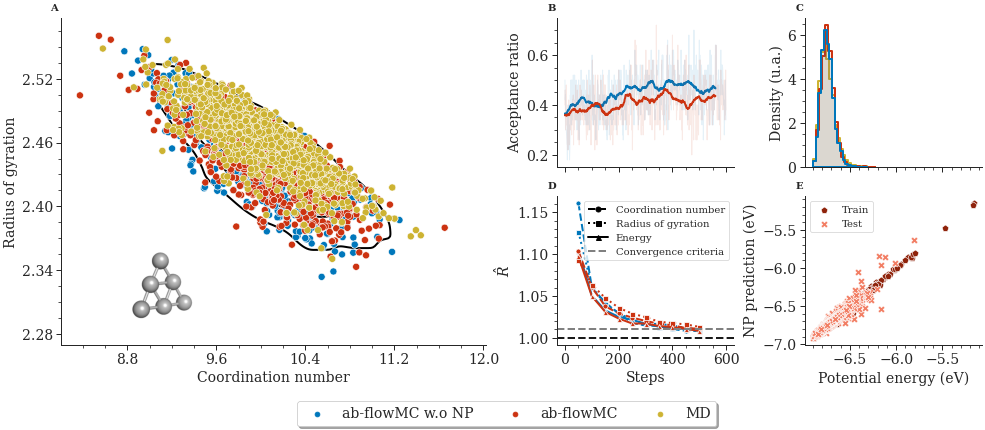

In [19]:
set_plot_figure_1(
    cvs_is0,
    flow_samples_is0,
    accs_is0,
    rhat_is0,
    energies_is0,
    np_predictions_is0,
    0,
    model_colors,
    figsize=(5.5*3, 2*3),
    fontsize=14,
    size_axes_label=14,
    size_tick_label=14,
    size_legend=10,
    linewidth=2,
    markersize=5,
    hspace=0.2,
    wspace=0.4,
)

#plt.savefig(path_to_save_figures+'figure_1_is0.png', 
#            dpi=300, 
#            facecolor='white',
#            transparent=False)

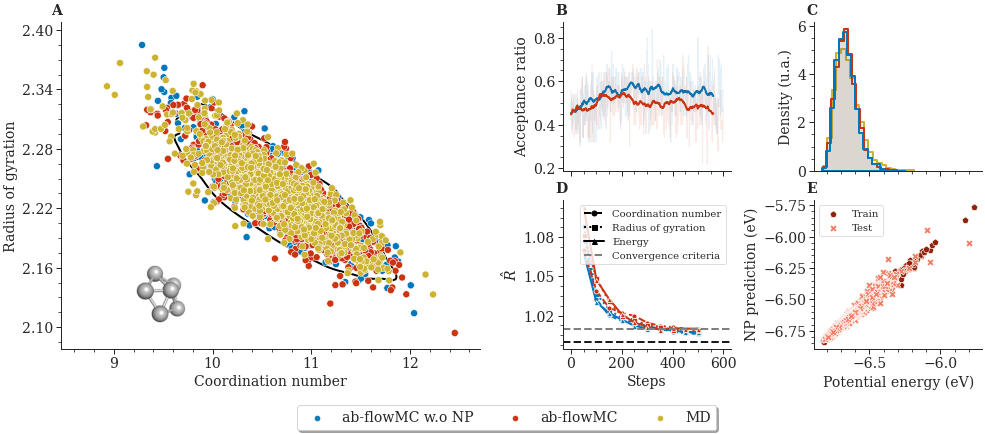

In [20]:
set_plot_figure_1(
    cvs_is1,
    flow_samples_is1,
    accs_is1,
    rhat_is1,
    energies_is1,
    np_predictions_is1,
    1,
    model_colors,
    figsize=(5.5*3, 2*3),
    fontsize=14,
    size_axes_label=14,
    size_tick_label=14,
    size_legend=10,
    linewidth=2,
    markersize=5,
    hspace=0.2,
    wspace=0.5,
)

#plt.savefig(path_to_save_figures+'figure_1_is1.png', 
#            dpi=300, 
#            facecolor='white', 
#            transparent=False)

## Figure 2

In [18]:
from flonacomldft.models.mixture import Mixture
from flonacomldft.internal_coordinates import Coordinates_mapping
from matplotlib.transforms import Bbox

In [19]:
# 350 K results
path = "/mnt/home/amolina/ceph/adaptive-350/adaptive-dft"
adaptive_dft_path = ['1-adaptive/results_adaptive_is0_28685740/adaptive_sampling_is0_28685740.pkl',
                    '1-adaptive/results_adaptive_is1_28685741/adaptive_sampling_is1_28685741.pkl']

adaptive_mlp_path = [#'2-adaptive-mlp/results_adaptive_is0_28706672/adaptive_sampling_is0_28706672.pkl',
                     '2-adaptive-mlp/results_adaptive_is0_29525786/adaptive_sampling_is0_29525786.pkl',
                    '2-adaptive-mlp/results_adaptive_is1_28707820/adaptive_sampling_is1_28707820.pkl']

adaptives_dft = {i: load_pickle_file(adaptive_dft_path[i], path) for i in range(0, 2)}
adaptives_mlp = {i: load_pickle_file(adaptive_mlp_path[i], path) for i in range(0, 2)}

In [20]:
# simulation files
#mcmc_paths = ['5-multimodal/results_multimodal_sampling_mixture_29096190/mixture_mcmc_dic_29096190.pkl',
#             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134160/mixture_mcmc_dic_29134160.pkl',
#             '6-multimodal-mlp/results_multimodal_sampling_mixture_29134161/mixture_mcmc_dic_29134161.pkl']

# load mcmc results
keys = ['ab-flowMM w.o NP', 'ab-flowMM']
color_keys = dict(zip(keys, ['blue', 'orange']))
model_colors = dict(zip(['ab-flowMM w.o NP', 'ab-flowMM'],
                        ['#0077BB', '#CC3311']))
mcmcs = {new_key: load_pickle_file('deprecated/mcmcs_sims.pkl', get_project_path() + '/data_for_plots')[old_key] for old_key, new_key in zip(['Ab-initio flow MC w.o NP Mixture Model', 
        'Ab-initio flow MC Mixture Model'], keys)}

cvs_mcmcs = {new_key: load_pickle_file('deprecated/cvs_mcmcs.pkl', get_project_path() + '/data_for_plots')[old_key] for old_key, new_key in zip(['Ab-initio flow MC w.o NP Mixture Model', 
        'Ab-initio flow MC Mixture Model'], keys)}

us = {key: mcmcs[key]['us'].flatten().detach() for key in keys}

weights = torch.tensor([0.75, 0.25]).detach()
mixture_models = {}
for key, adaptives in zip(keys, [adaptives_dft, adaptives_mlp]):
    flow_models = []
    for i in range(2):
        flow_models.append(adaptives[i]['dict_flows_training'][-1][0]['model'])
    mixture_model = Mixture(flow_models, weights)
    mixture_models[key] = mixture_model

def get_data_proposals(n_samples, mixture_model):
    samples, isomers = mixture_model.sample(n_samples, return_mus=True)
    target_log_prob = lambda x: -mixture_model.nll(x)
    coord_mapping = Coordinates_mapping()
    log_prob = torch.cat([target_log_prob(samples)[isomers == i] for i in range(2)]).reshape(-1, 1)
    cvs = torch.cat([ coord_mapping.get_collective_variables_from_real_centered(samples[isomers==i], isomer=i) for i in range(2)])
    data = pd.DataFrame(torch.cat((cvs, torch.exp(log_prob)), dim=1).detach(), columns=[CV1_label, CV2_label, 'Prob'])
    return data

data_proposals = {key: get_data_proposals(1000, mixture_models[key]) for key in keys}

time_sims = {}

for key in mcmcs.keys():
    time_sims[key] = mcmcs[key]['time_mcmc']
    min_time = min(time_sims[key])
    time_sims[key] = torch.tensor([t - min_time for t in time_sims[key]]).detach()
    time_sims[key] = time_sims[key] / 3600

rhat = {}

for key in keys:
    xss = torch.cat((cvs_mcmcs[key], 
                us[key].reshape(1000, 50, 1)), 
                dim=2).detach().numpy().transpose(1, 0, 2)

    rhat[key] = R_hat(xss, labels=[CV1_label, CV2_label, 'Energy'])

isomers = {key: mcmcs[key]['isomers'] for key in keys}

x = np.arange(0, 1000, 1)
y = np.arange(0, 50, 1)

X, Y = np.meshgrid(x, y)

z = isomers[keys[1]].detach().numpy().T
horzSum = np.sum(z, 1)
index_sort = np.argsort(horzSum)

In [21]:
from matplotlib.ticker import FormatStrFormatter
formatter = FormatStrFormatter('%.0f')

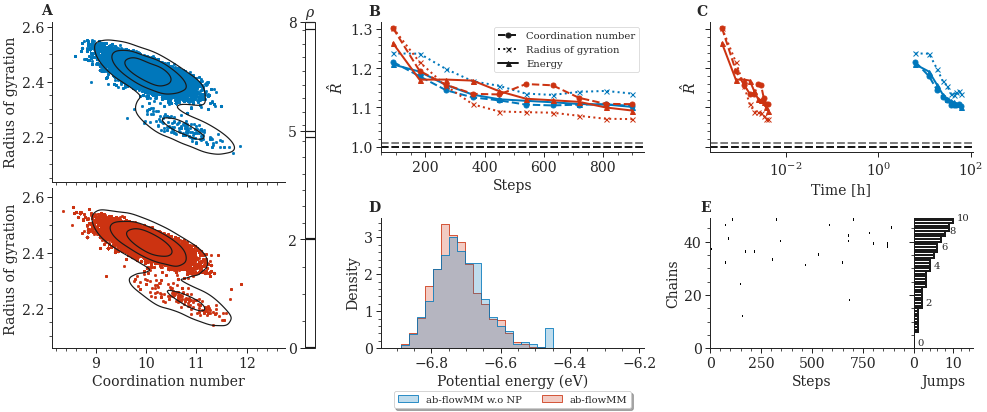

In [23]:
figsize=(5.5*3, 2*3)
fontsize=14
size_axes_label=14
size_tick_label=14
size_legend=10
linewidth=2
markersize=5
hspace=0.5
wspace=0.5

ncols = 5
nrows = 2

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })   

# ------ SET FIGURE SIZE ------

fig, axs = plt.subplots(ncols=ncols, 
                nrows=nrows, 
                figsize=figsize,
                gridspec_kw={'width_ratios': [0.95, 0.05, 1.335, 0.7, 0.3], #[0.95, 0.05, 0.8, 0.2, 1.335],
                'height_ratios': [1, 1],
                'wspace': wspace,
                'hspace': hspace}
                )
 
# ------ SUBPLOTS SET UP -------

# -- cvs subplots set up --
ax1 = axs[0][0]
ax2 = axs[1][0]

cbar_gs= axs[0][1].get_gridspec()
axs[0][1].remove()
axs[1][1].remove()

cbar_ax = fig.add_subplot(cbar_gs[0:, 1])

axs_scatter = [ax1, ax2]

# -- isomers subplots set up --

ax3 = axs[1][3]
ax4 = axs[1][4]

# -- energy subplot set up --

ax5 = axs[1][2]

# -- rhat subplots set up --

gs_rhat = axs[0][3].get_gridspec()
axs[0][3].remove()
axs[0][4].remove()

ax7 = fig.add_subplot(gs_rhat[0, 3:])

ax6 = axs[0][2]

axs_rhat = [ax6, ax7]

# -- item to subplot and delete top and right axis lines --

posx = -0.05
posy = 1.05

for n, ax in enumerate([ax1, ax6, ax7, ax5, ax3]):#, ax4]):
    ax.text(posx,
    posy, 
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

ax2.spines[['right', 'top']].set_visible(False)
ax4.spines[['left', 'right', 'top']].set_visible(False)

# -- sharing axis subplots --

ax2.sharex(ax1)
plt.setp(ax1.get_xticklabels(), visible=False)

ax3.sharey(ax4)
plt.setp(ax4.get_yticklabels(), visible=False)

#ax6.sharex(ax3)
#plt.setp(ax3.get_xticklabels(), visible=False)

ax6.sharey(ax7)
plt.setp(ax7.get_yticklabels(), visible=False)

# -- updating subplots positions --

for ax in [ax1, ax2]:

    update_position = ax.get_position().get_points()
    update_position[1][0] = cbar_ax.get_position().xmin*0.95
    ax.set_position(Bbox(update_position))

diff = ax1.get_position().get_points()[0][1] - ax2.get_position().get_points()[1][1]

ax1.set_position(Bbox(ax1.get_position().get_points() - np.array([[0, 1], [0, 0]])*(diff/2)*0.9))
ax2.set_position(Bbox(ax2.get_position().get_points() + np.array([[0, 0], [0, 1]])*(diff/2)*0.9))

update_position = ax3.get_position().get_points()
update_position[1][0] = ax4.get_position().xmin
ax3.set_position(Bbox(update_position))

# -- plotting cvs --

for i, key in enumerate(cvs_mcmcs.keys()):

    sns.kdeplot(data=data_proposals[key], x=CV1_label, y=CV2_label, 
                fill=False,
                color='k', 
                #cmap='GnBu', 
                ax=axs_scatter[i], cbar=True, cbar_ax=cbar_ax,
                levels=4,  cbar_kws={#'label': 'Proposal probability', 
                                     'format': formatter,
                                     }
                                    )

    for k in range(2):
        axs_scatter[i].scatter(cvs_mcmcs[key][isomers[key]==k][:, 0].flatten().detach(), 
                cvs_mcmcs[key][isomers[key]==k][:, 1].flatten().detach(), 
                s=markersize, 
                color=model_colors[key], 
                #label='Isomer {:d}'.format(k)
                )
    
        axs_scatter[i].set_xlabel('Coordination number')
        axs_scatter[i].set_ylabel('Radius of gyration')
        #axs_scatter[i].legend(loc='upper right')

cbar_ax.set_title(r'$\rho$')
cbar_ax.yaxis.set_ticks_position('left')

# -- plotting isomers --

ax3.imshow(z[index_sort, :], aspect='auto', cmap='gray_r', interpolation='none')
ax4.barh(np.array(range(len(horzSum)))-0.5, horzSum[index_sort], 1.1, color='white', edgecolor='k', linewidth=linewidth, alpha=1)
ax4.set_ylim(0, len(z)-1)

values, indexes = np.unique(horzSum[index_sort], return_index=True)

for index, value in zip(indexes[::2], values[::2]):
    ax4.text(value + 1, index + np.exp(-index*0.5),
             str(int(value)), fontsize=size_legend)
    
ax4.set_xlim(horzSum.min(), horzSum.max() + horzSum.max()*0.5)

ax3.set_xlabel('Steps')
ax3.set_ylabel('Chains')

ax4.set_xlabel('Jumps')

#ax4.set_xticks([])
#ax4.set_yticks([])

# -- plotting energy --

sns.histplot(us, ax=ax5, palette=model_colors, bins=30, 
                      element='step',
                      stat='density'
                      )

ax5.set_xlabel('Potential energy (eV)')

# -- plotting rhat --

markers = ['o', 'x', '^']
linestyles = ['dashed', 'dotted', '-']

for key in rhat.keys():
        for i in range(rhat[key][0].shape[-1]):
            axs_rhat[0].plot(rhat[key][1], 
                            rhat[key][0][:, i], 
                            linestyle=linestyles[i], 
                            marker=markers[i],
                            markersize=markersize,
                            linewidth=linewidth,
                            color=model_colors[key], 
                            label=rhat[key][2][i])

            axs_rhat[1].plot(time_sims[key][rhat[key][1]],
                            rhat[key][0][:, i],
                            linestyle=linestyles[i], 
                            marker=markers[i],
                            markersize=markersize,
                            linewidth=linewidth,
                            color=model_colors[key], 
                            label=rhat[key][2][i])
        
        axs_rhat[1].set_xlabel('Time [h]')
        axs_rhat[1].set_ylabel(r'$\hat{R}$')
        axs_rhat[1].axhline(1, c='k', ls='--', linewidth=linewidth)
        axs_rhat[1].axhline(1.01, c='grey', ls='--', linewidth=linewidth)
        axs_rhat[1].set_xscale('log')


        axs_rhat[0].axhline(1, c='k', ls='--', linewidth=linewidth)
        axs_rhat[0].axhline(1.01, c='grey', ls='--', linewidth=linewidth)
        axs_rhat[0].set_xlabel('Steps')
        axs_rhat[0].set_ylabel(r'$\hat{R}$')

j=0
colors = ["k"]*3
patches = [ axs_rhat[j].plot([],[], marker=markers[i], linestyle=linestyles[i], linewidth=linewidth, markersize=markersize, 
                             color=colors[i], 
            label="{:s}".format(rhat[key][2][i]) )[0]  for i in range(len(rhat[key][2])) ]
axs_rhat[j].legend(handles=patches)

sns.move_legend(ax5, "lower center", bbox_to_anchor=(0.5, -0.5),
            ncol=2, 
            fancybox=True, 
            shadow=True, 
            markerscale=markersize/5,
            )

plt.savefig(path_to_save_figures+'figure_2_mixture.png', 
            dpi=300, 
            facecolor='white', 
            transparent=False)

In [24]:
cbar_ax.get_position().get_points()[1][0] - ax1.get_position().get_points()[0][0]

0.2213455772113943

In [25]:
ax4.get_position().get_points()[1][0] - ax3.get_position().get_points()[0][0]

0.22134557721139425

In [26]:
ax7.get_position().get_points()[1][0] - ax7.get_position().get_points()[0][0]

0.22134557721139425